# 03 — Liquid staking versus liquid restaking: analysis

## Research question

Do liquid restaking tokens (LRTs) offer a yield premium over liquid staking tokens (LSTs), and is that premium associated with stronger protocol-TV L growth?

This notebook reads the two datasets created in Notebook 02:

- `staking_yield_timeseries.csv`
- `staking_tvl_timeseries.csv`

It produces four outputs:

1. total APY over time by token;
2. an LRT-minus-LST yield-premium series;
3. protocol TVL over time as an adoption proxy;
4. a descriptive relationship between APY and next-week relative TVL growth.

**Interpretation boundaries:** protocol TVL is an adoption proxy, not liquidity; do not sum protocol TVLs across products because ETH can pass through multiple layers. The APY/TVL analysis is descriptive and does not establish causality.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path("..")
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUTS = PROJECT_ROOT / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)

WEEK_END = "W-SUN"
ROLLING_WEEKS = 4

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

Matplotlib is building the font cache; this may take a moment.


## Read and validate the datasets

Notebook 03 makes no API calls. It only analyses the processed files created in Notebook 02.

In [3]:
mapping_path = DATA_PROCESSED / "protocol_mapping.csv"
yield_path = DATA_PROCESSED / "staking_yield_timeseries.csv"
tvl_path = DATA_PROCESSED / "staking_tvl_timeseries.csv"

for path in [mapping_path, yield_path, tvl_path]:
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path.name}. Run Notebooks 01 and 02 before this notebook."
        )

mapping_df = pd.read_csv(mapping_path)
yield_df = pd.read_csv(yield_path, parse_dates=["date"])
tvl_df = pd.read_csv(tvl_path, parse_dates=["date"])

required_mapping_columns = {
    "product_id", "protocol", "category", "token"
}

required_yield_columns = {
    "date", "product_id", "protocol", "category", "token", "apy_total"
}

required_tvl_columns = {
    "date", "product_id", "protocol", "category", "token", "tvl_usd"
}

for name, dataframe, required_columns in [
    ("protocol mapping", mapping_df, required_mapping_columns),
    ("yield history", yield_df, required_yield_columns),
    ("TVL history", tvl_df, required_tvl_columns),
]:
    missing_columns = required_columns.difference(dataframe.columns)

    assert not missing_columns, (
        f"{name} is missing columns: {sorted(missing_columns)}"
    )

for column in ["apy_total", "apy_base", "apy_reward", "pool_tvl_usd"]:
    if column not in yield_df.columns:
        yield_df[column] = pd.NA

    yield_df[column] = pd.to_numeric(
        yield_df[column],
        errors="coerce",
    )

tvl_df["tvl_usd"] = pd.to_numeric(
    tvl_df["tvl_usd"],
    errors="coerce",
)

yield_df = (
    yield_df
    .dropna(subset=["date", "apy_total"])
    .drop_duplicates(subset=["product_id", "date"])
    .sort_values(["product_id", "date"])
    .reset_index(drop=True)
)

tvl_df = (
    tvl_df
    .dropna(subset=["date", "tvl_usd"])
    .query("tvl_usd > 0")
    .drop_duplicates(subset=["product_id", "date"])
    .sort_values(["product_id", "date"])
    .reset_index(drop=True)
)

category_order = [
    "liquid_staking",
    "liquid_restaking",
]

assert set(yield_df["category"]).issubset(category_order)
assert set(tvl_df["category"]).issubset(category_order)

assert yield_df["product_id"].nunique() == 5, (
    "Expected five selected products."
)

assert tvl_df["product_id"].nunique() == 5, (
    "Expected five selected products."
)

print(f"Yield observations: {len(yield_df):,}")
print(f"TVL observations:   {len(tvl_df):,}")
print(f"Output directory:    {OUTPUTS}")

Yield observations: 4,826
TVL observations:   6,787
Output directory:    ..\outputs


## Data coverage

LRTs have shorter histories than the long-established LSTs. We therefore show each product's full available history, but also calculate the common overlap window for fair like-for-like summary statistics.


In [4]:
yield_coverage_df = (
    yield_df
    .groupby(
        ["product_id", "protocol", "category", "token"],
        as_index=False,
    )
    .agg(
        yield_start=("date", "min"),
        yield_end=("date", "max"),
        yield_observations=("date", "size"),
    )
)

tvl_coverage_df = (
    tvl_df
    .groupby(
        ["product_id", "protocol", "category", "token"],
        as_index=False,
    )
    .agg(
        tvl_start=("date", "min"),
        tvl_end=("date", "max"),
        tvl_observations=("date", "size"),
    )
)

coverage_df = (
    mapping_df[
        ["product_id", "protocol", "category", "token"]
    ]
    .merge(
        yield_coverage_df,
        on=["product_id", "protocol", "category", "token"],
        how="left",
        validate="one_to_one",
    )
    .merge(
        tvl_coverage_df,
        on=["product_id", "protocol", "category", "token"],
        how="left",
        validate="one_to_one",
    )
    .sort_values(["category", "token"])
    .reset_index(drop=True)
)

common_start = yield_coverage_df["yield_start"].max()
common_end = yield_coverage_df["yield_end"].min()
common_days = (common_end - common_start).days

print(
    "Common yield-observation window: "
    f"{common_start.date()} to {common_end.date()} "
    f"({common_days} days)"
)

display(coverage_df)

Common yield-observation window: 2024-12-13 to 2026-06-25 (558 days)


,product_id,protocol,category,token,yield_start,yield_end,yield_observations,tvl_start,tvl_end,tvl_observations
0,renzo_ezeth,Renzo,liquid_restaking,ezETH,2024-12-13 23:01:38.564,2026-06-25 15:02:35.015,560,2023-12-19 00:00:00,2026-06-25 15:14:47,920
1,kelp_rseth,Kelp DAO,liquid_restaking,rsETH,2024-05-07 23:01:57.812,2026-06-25 15:02:13.951,773,2023-12-21 00:00:00,2026-06-25 15:04:35,919
2,etherfi_weeth,Ether.fi,liquid_restaking,weETH,2024-06-05 23:01:34.685,2026-06-25 14:02:20.906,751,2023-03-02 00:00:00,2026-06-25 15:04:35,1204
3,rocket_pool_reth,Rocket Pool,liquid_staking,rETH,2023-01-16 23:02:00.705,2026-06-25 15:04:47.226,1257,2021-10-02 00:00:00,2026-06-25 14:28:35,1729
4,lido_steth,Lido,liquid_staking,stETH,2022-05-03 00:00:00.000,2026-06-25 15:03:30.122,1485,2020-12-19 23:00:00,2026-06-25 14:18:23,2015


## Convert to weekly observations

- APY is the weekly median of daily APY observations.
- TVL is the final available value in each week.
- Relative TVL growth means a product's growth minus the median growth of the five-product sample in that week.

In [5]:
def to_week_end(dates: pd.Series) -> pd.Series:
    return dates.dt.to_period(WEEK_END).dt.end_time.dt.normalize()


yield_weekly_df = yield_df.copy()
yield_weekly_df["week"] = to_week_end(
    yield_weekly_df["date"]
)

yield_weekly_df = (
    yield_weekly_df
    .groupby(
        ["product_id", "protocol", "category", "token", "week"],
        as_index=False,
        observed=True,
    )
    .agg(
        apy_total=("apy_total", "median"),
        apy_base=("apy_base", "median"),
        apy_reward=("apy_reward", "median"),
        pool_tvl_usd=("pool_tvl_usd", "last"),
    )
    .sort_values(["product_id", "week"])
    .reset_index(drop=True)
)

yield_weekly_df["apy_total_rolling_median"] = (
    yield_weekly_df
    .groupby("product_id", observed=True)["apy_total"]
    .transform(
        lambda series: series.rolling(
            window=ROLLING_WEEKS,
            min_periods=1,
        ).median()
    )
)

tvl_weekly_df = tvl_df.copy()
tvl_weekly_df["week"] = to_week_end(
    tvl_weekly_df["date"]
)

tvl_weekly_df = (
    tvl_weekly_df
    .sort_values(["product_id", "date"])
    .groupby(
        ["product_id", "protocol", "category", "token", "week"],
        as_index=False,
        observed=True,
    )
    .agg(tvl_usd=("tvl_usd", "last"))
    .sort_values(["product_id", "week"])
    .reset_index(drop=True)
)

tvl_weekly_df["tvl_growth_pct"] = (
    tvl_weekly_df
    .groupby("product_id", observed=True)["tvl_usd"]
    .pct_change()
    .mul(100)
)

tvl_weekly_df["sample_median_tvl_growth_pct"] = (
    tvl_weekly_df
    .groupby("week", observed=True)["tvl_growth_pct"]
    .transform("median")
)

tvl_weekly_df["relative_tvl_growth_pct"] = (
    tvl_weekly_df["tvl_growth_pct"]
    - tvl_weekly_df["sample_median_tvl_growth_pct"]
)

print(f"Weekly APY observations: {len(yield_weekly_df):,}")
print(f"Weekly TVL observations: {len(tvl_weekly_df):,}")

Weekly APY observations: 697
Weekly TVL observations: 974


## 1. Yield evolution by token

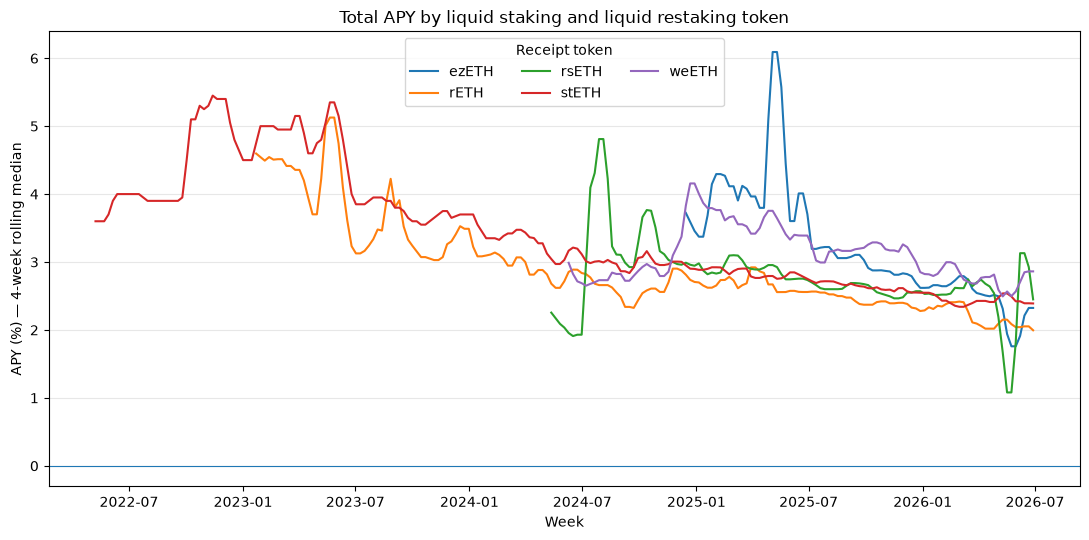

Saved: ..\outputs\01_total_apy_by_token.png


In [6]:
fig, ax = plt.subplots(figsize=(11, 5.5))

for _, token_data in yield_weekly_df.groupby("token", sort=True):
    token_data = token_data.sort_values("week")

    ax.plot(
        token_data["week"],
        token_data["apy_total_rolling_median"],
        label=token_data["token"].iloc[0],
    )

ax.axhline(0, linewidth=0.8)
ax.set_title("Total APY by liquid staking and liquid restaking token")
ax.set_xlabel("Week")
ax.set_ylabel("APY (%) — 4-week rolling median")
ax.legend(title="Receipt token", ncols=3)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

figure_path = OUTPUTS / "01_total_apy_by_token.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")

plt.show()

print(f"Saved: {figure_path}")

## 2. Yield level and stability

In [14]:
def interquartile_range(series: pd.Series) -> float:
    return series.quantile(0.75) - series.quantile(0.25)


def build_yield_summary(data: pd.DataFrame) -> pd.DataFrame:
    return (
        data
        .groupby(
            ["protocol", "category", "token"],
            as_index=False,
            observed=True,
        )
        .agg(
            weeks=("week", "size"),
            mean_apy=("apy_total", "mean"),
            median_apy=("apy_total", "median"),
            apy_std=("apy_total", "std"),
            apy_iqr=("apy_total", interquartile_range),
            min_apy=("apy_total", "min"),
            max_apy=("apy_total", "max"),
            median_base_apy=("apy_base", "median"),
            median_reward_apy=("apy_reward", "median"),
        )
        .sort_values(
            ["category", "median_apy"],
            ascending=[True, False],
        )
        .reset_index(drop=True)
    )


full_yield_summary_df = build_yield_summary(
    yield_weekly_df
)

common_yield_weekly_df = yield_weekly_df.loc[
    (yield_weekly_df["week"] >= common_start)
    & (yield_weekly_df["week"] <= common_end)
].copy()

common_yield_summary_df = build_yield_summary(
    common_yield_weekly_df
)

print("Full available history")
display(full_yield_summary_df)

print("Common overlap window only")
display(common_yield_summary_df)

if common_yield_weekly_df["week"].nunique() < 8:
    print(
        "Warning: the common window has fewer than 8 weekly observations. "
        "Treat this comparison as descriptive only."
    )

Full available history


,protocol,category,token,weeks,mean_apy,median_apy,apy_std,apy_iqr,min_apy,max_apy,median_base_apy,median_reward_apy
0,Ether.fi,liquid_restaking,weETH,108,3.12,3.08,0.43,0.55,2.44,4.48,2.84,0.30
1,Renzo,liquid_restaking,ezETH,81,3.19,2.93,0.94,0.95,1.59,6.91,2.93,NaN
2,Kelp DAO,liquid_restaking,rsETH,112,2.80,2.74,0.63,0.46,0.50,5.23,2.74,NaN
3,Lido,liquid_staking,stETH,216,3.44,3.15,0.92,1.16,2.32,6.90,3.15,NaN
4,Rocket Pool,liquid_staking,rETH,180,2.93,2.72,0.75,0.75,1.92,5.95,2.72,NaN


Common overlap window only


,protocol,category,token,weeks,mean_apy,median_apy,apy_std,apy_iqr,min_apy,max_apy,median_base_apy,median_reward_apy
0,Ether.fi,liquid_restaking,weETH,80,3.19,3.17,0.42,0.56,2.44,4.48,2.85,0.30
1,Renzo,liquid_restaking,ezETH,80,3.21,2.93,0.94,0.95,1.59,6.91,2.93,NaN
2,Kelp DAO,liquid_restaking,rsETH,80,2.66,2.69,0.44,0.33,0.50,3.63,2.69,NaN
3,Lido,liquid_staking,stETH,80,2.65,2.65,0.19,0.26,2.32,3.16,2.65,NaN
4,Rocket Pool,liquid_staking,rETH,80,2.45,2.43,0.28,0.28,1.93,3.37,2.43,NaN


## 3. LRT yield premium over LSTs

Positive values mean the typical LRT had a higher quoted APY than the typical LST in that week.

,common_weeks,mean_lrt_premium_pp,median_lrt_premium_pp,share_of_weeks_lrt_higher
0,112,0.36,0.39,0.90


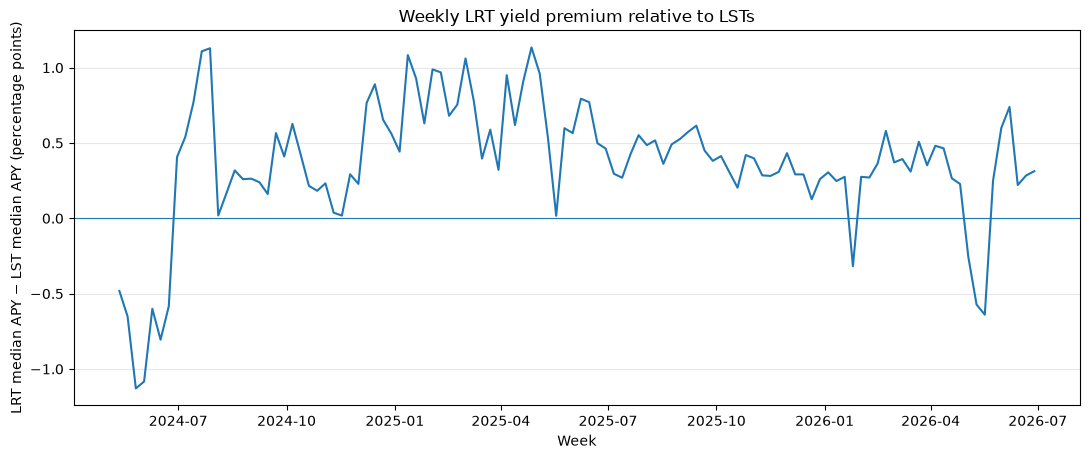

Saved: ..\outputs\02_lrt_yield_premium.png


In [7]:
category_weekly_df = (
    yield_weekly_df
    .groupby(
        ["week", "category"],
        as_index=False,
        observed=True,
    )
    .agg(category_median_apy=("apy_total", "median"))
)

category_apy_pivot_df = (
    category_weekly_df
    .pivot(
        index="week",
        columns="category",
        values="category_median_apy",
    )
    .reindex(columns=category_order)
    .dropna()
    .reset_index()
)

category_apy_pivot_df["lrt_minus_lst_apy_pp"] = (
    category_apy_pivot_df["liquid_restaking"]
    - category_apy_pivot_df["liquid_staking"]
)

premium_summary_df = pd.DataFrame(
    {
        "common_weeks": [len(category_apy_pivot_df)],
        "mean_lrt_premium_pp": [
            category_apy_pivot_df["lrt_minus_lst_apy_pp"].mean()
        ],
        "median_lrt_premium_pp": [
            category_apy_pivot_df["lrt_minus_lst_apy_pp"].median()
        ],
        "share_of_weeks_lrt_higher": [
            (
                category_apy_pivot_df["lrt_minus_lst_apy_pp"] > 0
            ).mean()
        ],
    }
)

display(premium_summary_df)

fig, ax = plt.subplots(figsize=(11, 4.7))

ax.plot(
    category_apy_pivot_df["week"],
    category_apy_pivot_df["lrt_minus_lst_apy_pp"],
)

ax.axhline(0, linewidth=0.8)
ax.set_title("Weekly LRT yield premium relative to LSTs")
ax.set_xlabel("Week")
ax.set_ylabel(
    "LRT median APY − LST median APY (percentage points)"
)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

figure_path = OUTPUTS / "02_lrt_yield_premium.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")

plt.show()

print(f"Saved: {figure_path}")

## 4. TVL evolution: adoption proxy

This is protocol TVL, not a deduplicated total market size. Never add the five lines together.

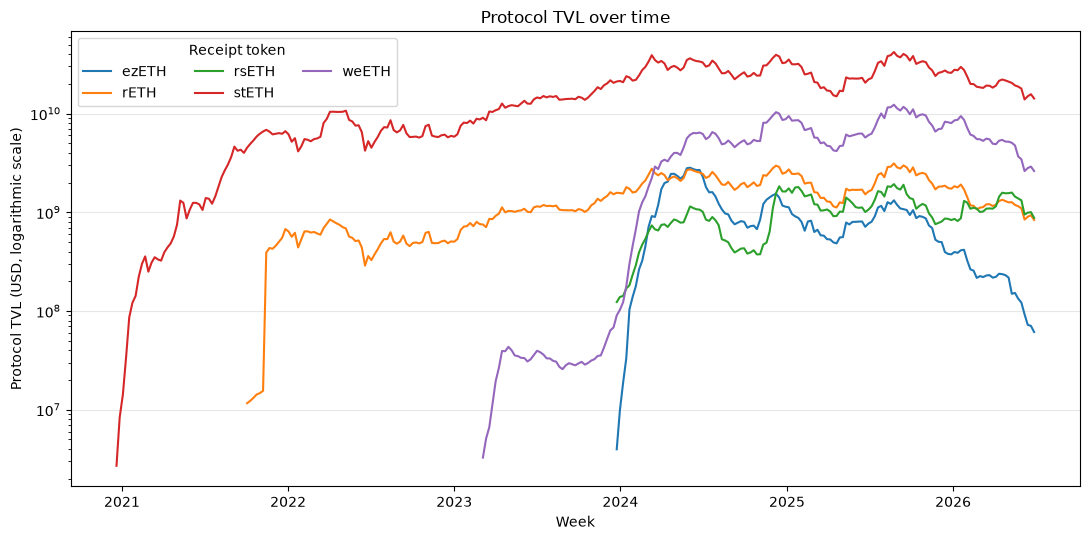

Saved: ..\outputs\03_protocol_tvl_by_token.png


In [9]:
fig, ax = plt.subplots(figsize=(11, 5.5))

for _, token_data in tvl_weekly_df.groupby("token", sort=True):
    token_data = token_data.sort_values("week")

    ax.plot(
        token_data["week"],
        token_data["tvl_usd"],
        label=token_data["token"].iloc[0],
    )

ax.set_yscale("log")
ax.set_title("Protocol TVL over time")
ax.set_xlabel("Week")
ax.set_ylabel("Protocol TVL (USD, logarithmic scale)")
ax.legend(title="Receipt token", ncols=3)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

figure_path = OUTPUTS / "03_protocol_tvl_by_token.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")

plt.show()

print(f"Saved: {figure_path}")

## 5. APY and later TVL growth

We compare APY in week t with relative TVL growth in week t + 1.

This is an association only. It cannot prove that higher APY caused capital inflows.

Pooled descriptive association


,observations,pearson_correlation,spearman_correlation
0,692,-0.02,-0.10


Within-product descriptive association


,protocol,category,token,observations,pearson_correlation,spearman_correlation
0,Renzo,liquid_restaking,ezETH,80.00,0.23,0.19
1,Rocket Pool,liquid_staking,rETH,179.00,-0.06,-0.19
2,Kelp DAO,liquid_restaking,rsETH,111.00,-0.06,-0.14
3,Lido,liquid_staking,stETH,215.00,-0.03,-0.24
4,Ether.fi,liquid_restaking,weETH,107.00,-0.01,0.11


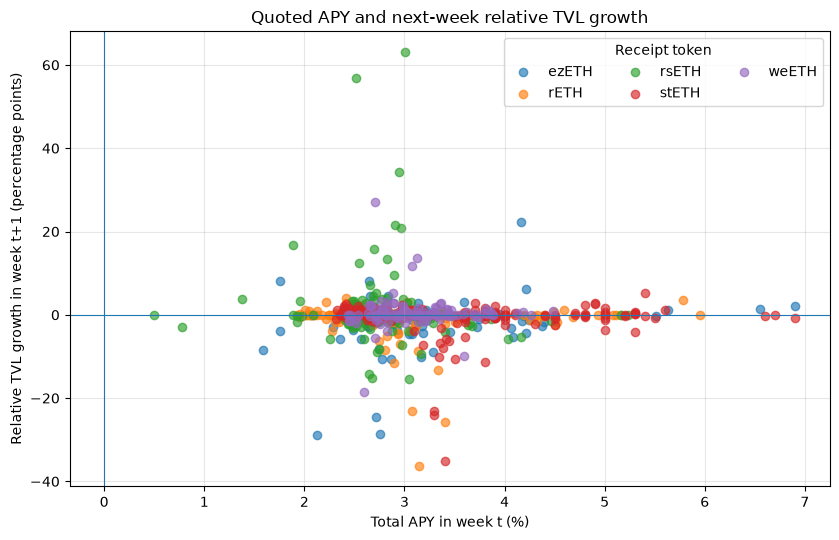

Saved: ..\outputs\04_apy_vs_next_week_tvl_growth.png


In [12]:
join_columns = [
    "product_id",
    "protocol",
    "category",
    "token",
    "week",
]

growth_next_week_df = tvl_weekly_df[
    join_columns + ["relative_tvl_growth_pct"]
].copy()

# Shift next week's TVL growth back by one week, so it aligns with APY in week t.
growth_next_week_df["week"] = (
    growth_next_week_df["week"]
    - pd.Timedelta(days=7)
)

growth_next_week_df = growth_next_week_df.rename(
    columns={
        "relative_tvl_growth_pct":
        "next_week_relative_tvl_growth_pct"
    }
)

association_df = (
    yield_weekly_df
    .merge(
        growth_next_week_df,
        on=join_columns,
        how="inner",
        validate="one_to_one",
    )
    .dropna(
        subset=[
            "apy_total",
            "next_week_relative_tvl_growth_pct",
        ]
    )
)


def spearman_without_scipy(
    x: pd.Series,
    y: pd.Series,
) -> float:
    """
    Spearman correlation = Pearson correlation of the ranked values.
    This avoids pandas' SciPy dependency for method='spearman'.
    """

    paired_df = pd.DataFrame(
        {
            "x": x,
            "y": y,
        }
    ).dropna()

    if len(paired_df) < 3:
        return np.nan

    ranked_x = paired_df["x"].rank(method="average")
    ranked_y = paired_df["y"].rank(method="average")

    return ranked_x.corr(ranked_y, method="pearson")


pooled_association_df = pd.DataFrame(
    {
        "observations": [len(association_df)],
        "pearson_correlation": [
            association_df["apy_total"].corr(
                association_df[
                    "next_week_relative_tvl_growth_pct"
                ],
                method="pearson",
            )
        ],
        "spearman_correlation": [
            spearman_without_scipy(
                association_df["apy_total"],
                association_df[
                    "next_week_relative_tvl_growth_pct"
                ],
            )
        ],
    }
)


def correlation_summary(group: pd.DataFrame) -> pd.Series:
    if len(group) < 3:
        return pd.Series(
            {
                "observations": len(group),
                "pearson_correlation": pd.NA,
                "spearman_correlation": pd.NA,
            }
        )

    return pd.Series(
        {
            "observations": len(group),
            "pearson_correlation": group["apy_total"].corr(
                group["next_week_relative_tvl_growth_pct"],
                method="pearson",
            ),
            "spearman_correlation": spearman_without_scipy(
                group["apy_total"],
                group["next_week_relative_tvl_growth_pct"],
            ),
        }
    )


product_association_df = (
    association_df
    .groupby(
        ["protocol", "category", "token"],
        observed=True,
    )
    .apply(correlation_summary)
    .reset_index()
    .sort_values("token")
    .reset_index(drop=True)
)

print("Pooled descriptive association")
display(pooled_association_df)

print("Within-product descriptive association")
display(product_association_df)

fig, ax = plt.subplots(figsize=(8.5, 5.5))

for _, token_data in association_df.groupby("token", sort=True):
    ax.scatter(
        token_data["apy_total"],
        token_data["next_week_relative_tvl_growth_pct"],
        label=token_data["token"].iloc[0],
        alpha=0.65,
    )

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

ax.set_title("Quoted APY and next-week relative TVL growth")
ax.set_xlabel("Total APY in week t (%)")
ax.set_ylabel(
    "Relative TVL growth in week t+1 (percentage points)"
)
ax.legend(title="Receipt token", ncols=3)
ax.grid(alpha=0.3)

fig.tight_layout()

figure_path = OUTPUTS / "04_apy_vs_next_week_tvl_growth.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")

plt.show()

print(f"Saved: {figure_path}")

## Liquidity context

This is intentionally qualitative. We do not create an arbitrary liquidity score.

In [13]:
liquidity_context_df = pd.DataFrame(
    [
        {
            "position": "Native staking",
            "tradeable_receipt_token": "No",
            "main_exit_route": "Validator withdrawal",
            "interpretation": "Lowest practical liquidity",
        },
        {
            "position": "Liquid staking token (LST)",
            "tradeable_receipt_token": "Yes",
            "main_exit_route":
            "Secondary-market sale or protocol withdrawal",
            "interpretation": "High practical liquidity",
        },
        {
            "position": "Direct restaking",
            "tradeable_receipt_token": "Usually no",
            "main_exit_route": "Restaking withdrawal process",
            "interpretation":
            "Lower liquidity and more operational complexity",
        },
        {
            "position": "Liquid restaking token (LRT)",
            "tradeable_receipt_token": "Yes",
            "main_exit_route":
            "Secondary-market sale or protocol withdrawal",
            "interpretation":
            "Tradeable, but with additional layers of exposure",
        },
    ]
)

display(liquidity_context_df)

,position,tradeable_receipt_token,main_exit_route,interpretation
0,Native staking,No,Validator withdrawal,Lowest practical liquidity
1,Liquid staking token (LST),Yes,Secondary-market sale or protocol withdrawal,High practical liquidity
2,Direct restaking,Usually no,Restaking withdrawal process,Lower liquidity and more operational complexity
3,Liquid restaking token (LRT),Yes,Secondary-market sale or protocol withdrawal,"Tradeable, but with additional layers of exposure"


# Conclusions

Our initial project compared broad DeFi yield categories such as staking, lending, and stablecoin yields. After the feedback, we narrowed the analysis to one common underlying asset — ETH — and compared two directly related product types:

- **Liquid staking tokens (LSTs):** stETH and rETH
- **Liquid restaking tokens (LRTs):** ezETH, rsETH, and weETH

This allowed us to examine whether the additional restaking layer provides a meaningful yield advantage and whether this advantage is reflected in adoption.

## 1. Liquid restaking usually provided a yield premium

Over the common observation period, LRTs generally offered higher APYs than LSTs. The weekly LRT premium was positive for most weeks and was often between approximately **0.2 and 1 percentage point**.

However, the premium was not constant. There were several weeks in which the LRT median APY was equal to or below the LST median APY. Therefore, liquid restaking should not be interpreted as offering a guaranteed higher return; instead, it offered a **frequent but variable yield premium**.

## 2. The extra yield came with higher variability

The LST yields, especially stETH and rETH, became relatively stable around the 2–3% range in the later part of the sample.

In contrast, LRT yields showed more pronounced spikes and declines. For example, ezETH and rsETH experienced periods of substantially higher yields, but also larger short-term changes. This suggests that the additional yield associated with liquid restaking may come with less predictable returns and more complex reward dynamics.

## 3. Higher APY alone did not explain adoption

The TVL chart shows that stETH remained by far the largest product throughout the sample. LRTs grew quickly after their introduction, especially weETH, but their TVL remained below stETH and was not consistently increasing over time.

The scatterplot also does not show a strong positive relationship between quoted APY and next-week relative TVL growth. Most observations cluster around low relative growth rates across different APY levels, while both large inflows and large outflows occurred at moderate APYs.

Therefore, a higher quoted yield alone does not appear sufficient to explain capital flows into these products.

## 4. Adoption likely depends on more than yield

The results suggest that users also value factors beyond APY, including:

- protocol size and reputation;
- perceived smart-contract and slashing risk;
- depth of secondary-market liquidity;
- withdrawal and redemption conditions;
- DeFi integrations and collateral usefulness;
- temporary incentives, points programmes, and market expectations.

This helps explain why stETH retained the largest TVL despite LRTs frequently offering a higher yield.

## Overall conclusion

Liquid restaking generally offered a modest but variable yield premium over liquid staking. However, the data does not show that this premium consistently translated into stronger subsequent TVL growth.

Our results therefore support the view that LRTs are not simply “higher-yield LSTs.” They offer additional return opportunities, but also add complexity, additional protocol dependencies, and potentially less predictable reward dynamics. For users, the relevant trade-off is not only return, but also stability, trust, liquidity, and risk.

## Limitations

This analysis is descriptive and does not establish causality. TVL is used as an adoption proxy, not as a direct measure of liquidity. In addition, LRTs have shorter histories than LSTs, and some observed APY differences may reflect temporary incentives or changing reward mechanisms rather than a permanent structural yield advantage.